# Questão 5 - Análise de Clientes Fiéis

## Cenário
A Diretoria da LH Nautical deseja identificar clientes fiéis. Um cliente fiel é aquele que possui:
- **Gasto médio alto por transação** (Ticket Médio)
- **Diversidade de compras** em diferentes categorias

O objetivo é mapear o que esses clientes de elite estão consumindo para replicar o comportamento em outros segmentos.

## Critérios de Elegibilidade
- **Filtro de Elite**: Apenas clientes com 3+ categorias distintas
- **Ranking**: Top 10 por Ticket Médio
- **Desempate**: id_cliente em ordem crescente

## Métricas
1. **Faturamento Total**: Soma do valor de todas as compras
2. **Frequência**: Número total de transações
3. **Ticket Médio**: Faturamento Total / Frequência
4. **Diversidade**: Quantidade de categorias distintas


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import unicodedata
import re

# Configurar matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Carregar Dados de Vendas e Produtos

In [7]:
# Carregar vendas normalizadas
vendas = pd.read_csv('datasets/vendas_normalizado.csv')
vendas['sale_date'] = pd.to_datetime(vendas['sale_date'], dayfirst=True, errors='coerce')
vendas = vendas.dropna(subset=['sale_date'])
vendas['qtd'] = pd.to_numeric(vendas['qtd'], errors='coerce')
vendas['total'] = pd.to_numeric(vendas['total'], errors='coerce')
vendas = vendas.dropna(subset=['qtd', 'total'])

# Carregar produtos raw para limpeza de categorias
produtos = pd.read_csv('datasets/produtos_raw.csv')

print(f'Vendas carregadas: {len(vendas)} transações')
print(f'Produtos carregados: {len(produtos)} produtos')
print(f'\nColunas de vendas: {vendas.columns.tolist()}')
print(f'Columnas de produtos: {produtos.columns.tolist()}')
print(f'\nPrimeiras linhas de vendas:')
print(vendas.head())
print(f'\nPrimeiras linhas de produtos:')
print(produtos.head())

Vendas carregadas: 1950 transações
Produtos carregados: 157 produtos

Colunas de vendas: ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date']
Columnas de produtos: ['name', 'price', 'code', 'actual_category']

Primeiras linhas de vendas:
   id  id_client  id_product  qtd      total  sale_date
0   0         42         105   11     3405.0 2023-09-10
1   4         20          23    5    55893.0 2023-02-03
2   5          8          57    4   451403.9 2024-02-12
3  11         39         128    5    23254.0 2023-05-07
4  17         43          91   11  1409558.7 2023-09-05

Primeiras linhas de produtos:
                             name        price  code        actual_category
0     Transponder AIS Maré Magnum  R$ 33122.52     1            ELETRONICOS
1       Transponder Furuno Marlin  R$ 13998.15     2            ELETRONICOS
2    Radar Furuno Pulse Leviathan   R$ 9024.19     3  E L E T R Ô N I C O S
3       Rádio AIS Hydro Tidal Zen   R$ 3381.88     4            Eletrunicos
4  Pi

## 2. Limpar e Normalizar Categorias de Produtos

In [8]:
# Função para normalizar texto (remover espaços, acentos, padronizar caso)
def normalizar_categoria(categoria):
    if pd.isna(categoria):
        return ''
    # Converter para string
    cat = str(categoria)
    # Remover espaços extras
    cat = re.sub(r'\s+', '', cat)
    # Converter para uppercase
    cat = cat.upper()
    # Remover acentos e caracteres especiais
    cat = ''.join(c for c in unicodedata.normalize('NFD', cat) if unicodedata.category(c) != 'Mn')
    return cat

# Aplicar normalização
produtos['categoria_normalizada'] = produtos['actual_category'].apply(normalizar_categoria)

# Verificar quantas categorias únicas existem
print(f'Categorias original (únicas): {produtos["actual_category"].nunique()}')
print(f'\nExemplos de variações:')
print(produtos['actual_category'].unique()[:20])

print(f'\nCategorias após normalização (únicas): {produtos["categoria_normalizada"].nunique()}')
print(f'\nCategorias normalizadas:')
print(produtos['categoria_normalizada'].unique())

# Manter apenas code e categoria normalizada
produtos_clean = produtos[['code', 'categoria_normalizada']].copy()
produtos_clean.columns = ['id_product', 'categoria']

print(f'\nProdutos limpos: {len(produtos_clean)} produtos')
print(produtos_clean.head())

Categorias original (únicas): 39

Exemplos de variações:
<StringArray>
[          'ELETRONICOS', 'E L E T R Ô N I C O S',           'Eletrunicos',
           'Eletronicoz',           'eLeTrÔnIcOs',           'eletrônicos',
           'Eletrônicos',          'Eletroniscos',           'Eletronicos',
           'eletronicos',           'EletrônicoS',           'ELEtRÔNICOS',
             'PROPULSAO',             'Propulção',                  'Prop',
            'Propulssão',             'propulsao',     'P R O P U L S Ã O',
              'Propução',             'propulsão']
Length: 20, dtype: str

Categorias após normalização (únicas): 18

Categorias normalizadas:
<StringArray>
[ 'ELETRONICOS',  'ELETRUNICOS',  'ELETRONICOZ', 'ELETRONISCOS',
    'PROPULSAO',    'PROPULCAO',         'PROP',   'PROPULSSAO',
     'PROPUCAO',    'PROPULSAM',    'ANCORAGEM',    'ENCORAGEM',
   'ANCORAGUEM',     'ANCORAJM',    'ANCORAJEM',     'ENCORAGI',
    'ANCORAJEN',    'ANCORAGEN']
Length: 18, dtype: str


## 3. Cruzar Vendas com Produtos Limpos e Calcular Métricas por Cliente

In [9]:
# Cruzar vendas com produtos limpos
vendas_com_categoria = vendas.merge(
    produtos_clean,
    left_on='id_product',
    right_on='id_product',
    how='left'
)

# Verificar se houve alguma venda sem categoria
print(f'Vendas com categoria: {vendas_com_categoria["categoria"].notna().sum()}')
print(f'Vendas sem categoria: {vendas_com_categoria["categoria"].isna().sum()}')

# Remover vendas sem categoria
vendas_com_categoria = vendas_com_categoria.dropna(subset=['categoria'])

print(f'\nVendas utilizadas: {len(vendas_com_categoria)}')

# Calcular métricas por cliente
metricas_cliente = vendas_com_categoria.groupby('id_client').agg({
    'total': 'sum',  # Faturamento total
    'id': 'count',   # Frequência (número de transações)
    'categoria': lambda x: x.nunique()  # Diversidade de categorias
}).reset_index()

metricas_cliente.columns = ['id_client', 'faturamento_total', 'frequencia', 'diversidade_categorias']

# Calcular ticket médio
metricas_cliente['ticket_medio'] = metricas_cliente['faturamento_total'] / metricas_cliente['frequencia']

# Ordenar por clareza
metricas_cliente = metricas_cliente[['id_client', 'faturamento_total', 'frequencia', 'ticket_medio', 'diversidade_categorias']]

print(f'\nMétricas por cliente calculadas:')
print(metricas_cliente.head(10))
print(f'\nResumo estatístico:')
print(metricas_cliente[['ticket_medio', 'diversidade_categorias']].describe())

Vendas com categoria: 2009
Vendas sem categoria: 0

Vendas utilizadas: 2009

Métricas por cliente calculadas:
   id_client  faturamento_total  frequencia   ticket_medio  \
0          1         7037901.85          35  201082.910000   
1          2        17517432.25          56  312811.290179   
2          3        15100506.30          51  296088.358824   
3          4        16357867.05          42  389473.025000   
4          5         5833600.60          29  201158.641379   
5          6         7820665.00          38  205806.973684   
6          7         6917283.75          35  197636.678571   
7          8        12330041.20          39  316154.902564   
8          9        12408407.25          44  282009.255682   
9         10        15896936.45          46  345585.575000   

   diversidade_categorias  
0                      13  
1                      15  
2                      13  
3                      14  
4                      12  
5                      11  
6          

## 4. Filtrar Clientes de Elite (3+ categorias, Top 10 por Ticket Médio)

In [10]:
# Aplicar filtro de diversidade (>= 3 categorias)
clientes_elite_candidatos = metricas_cliente[metricas_cliente['diversidade_categorias'] >= 3].copy()

print(f'Clientes com 3+ categorias: {len(clientes_elite_candidatos)} de {len(metricas_cliente)}')
print(f'\nPrimeiros clientes antes de ordenar e filtrar:')
print(clientes_elite_candidatos.head())

# Ordenar por Ticket Médio (decrescente) e id_client (crescente) para desempate
clientes_elite_candidatos = clientes_elite_candidatos.sort_values(
    by=['ticket_medio', 'id_client'],
    ascending=[False, True]
).reset_index(drop=True)

print(f'\nClientes após ordenação (primeiros 15):')
print(clientes_elite_candidatos[['id_client', 'ticket_medio', 'diversidade_categorias']].head(15))

# Selecionar top 10
clientes_fieis = clientes_elite_candidatos.head(10).copy()

print(f'\nTotal de clientes fiéis selecionados: {len(clientes_fieis)}')
print(f'Dados dos clientes fiéis:')
print(clientes_fieis)

print(f'\n🏆 TOP 10 CLIENTES FIÉIS:')
print('='*80)
if len(clientes_fieis) > 0:
    for idx, row in clientes_fieis.iterrows():
        print(f"{int(row['id_client']):3d} | Ticket Médio: R$ {row['ticket_medio']:10.2f} | Frequência: {int(row['frequencia']):3d} | Diversidade: {int(row['diversidade_categorias']):1d} categorias | Faturamento: R$ {row['faturamento_total']:12.2f}")
else:
    print("ERRO: Nenhum cliente fiel foi encontrado!")
print('='*80)

# Guardar lista de IDs dos clientes fiéis
ids_fieis = clientes_fieis['id_client'].tolist()
print(f'\nIDs dos clientes fiéis: {ids_fieis}')

Clientes com 3+ categorias: 49 de 49

Primeiros clientes antes de ordenar e filtrar:
   id_client  faturamento_total  frequencia   ticket_medio  \
0          1         7037901.85          35  201082.910000   
1          2        17517432.25          56  312811.290179   
2          3        15100506.30          51  296088.358824   
3          4        16357867.05          42  389473.025000   
4          5         5833600.60          29  201158.641379   

   diversidade_categorias  
0                      13  
1                      15  
2                      13  
3                      14  
4                      12  

Clientes após ordenação (primeiros 15):
    id_client   ticket_medio  diversidade_categorias
0          26  479364.313750                      12
1           4  389473.025000                      14
2          18  388946.634286                      13
3          31  387935.935000                       9
4          47  383291.019118                      12
5          10  

## 5. Analisar Categoria Mais Vendida para Clientes de Elite

In [11]:
# Filtrar vendas dos clientes fiéis
vendas_fieis = vendas_com_categoria[vendas_com_categoria['id_client'].isin(ids_fieis)].copy()

print(f'Total de transações dos 10 clientes fiéis: {len(vendas_fieis)}')

# Agrupar por categoria e somar quantidade
categoria_vendida = vendas_fieis.groupby('categoria').agg({
    'qtd': 'sum',
    'total': ['sum', 'count']
}).reset_index()

# Simplificar nomes de colunas
categoria_vendida.columns = ['categoria', 'quantidade_total', 'faturamento_total', 'numero_transacoes']

# Ordenar por quantidade (decrescente)
categoria_vendida = categoria_vendida.sort_values('quantidade_total', ascending=False)

# Categoria mais vendida
categoria_top = categoria_vendida.iloc[0]

print(f'\n⭐ CATEGORIA MAIS VENDIDA ENTRE CLIENTES FIÉIS:')
print('='*80)
print(f'Categoria: {categoria_top["categoria"]}')
print(f'Quantidade Total de Itens: {categoria_top["quantidade_total"]:.0f} unidades')
print(f'Faturamento Total: R$ {categoria_top["faturamento_total"]:.2f}')
print(f'Número de Transações: {categoria_top["numero_transacoes"]:.0f}')
print('='*80)

print(f'\n📊 DISTRIBUIÇÃO DE QUANTIDADE POR CATEGORIA (Clientes Fiéis):')
print(categoria_vendida)

# Calcular percentual de cada categoria
categoria_vendida['percentual'] = (categoria_vendida['quantidade_total'] / categoria_vendida['quantidade_total'].sum()) * 100
print(f'\nCom percentuais:')
print(categoria_vendida)

Total de transações dos 10 clientes fiéis: 409

⭐ CATEGORIA MAIS VENDIDA ENTRE CLIENTES FIÉIS:
Categoria: PROPULSAO
Quantidade Total de Itens: 753 unidades
Faturamento Total: R$ 68528301.40
Número de Transações: 81

📊 DISTRIBUIÇÃO DE QUANTIDADE POR CATEGORIA (Clientes Fiéis):
       categoria  quantidade_total  faturamento_total  numero_transacoes
16     PROPULSAO               753        68528301.40                 81
6    ELETRONICOS               723        12392360.05                 87
0      ANCORAGEM               476         1140436.40                 63
13      PROPUCAO               249        21185944.55                 26
14     PROPULCAO               175        11109671.00                 22
17    PROPULSSAO               172        15523674.55                 21
7    ELETRONICOZ               146         2975703.20                 19
2     ANCORAGUEM               121          255540.00                 17
12          PROP               117        11343720.25             

## 6. Visualizações dos Resultados

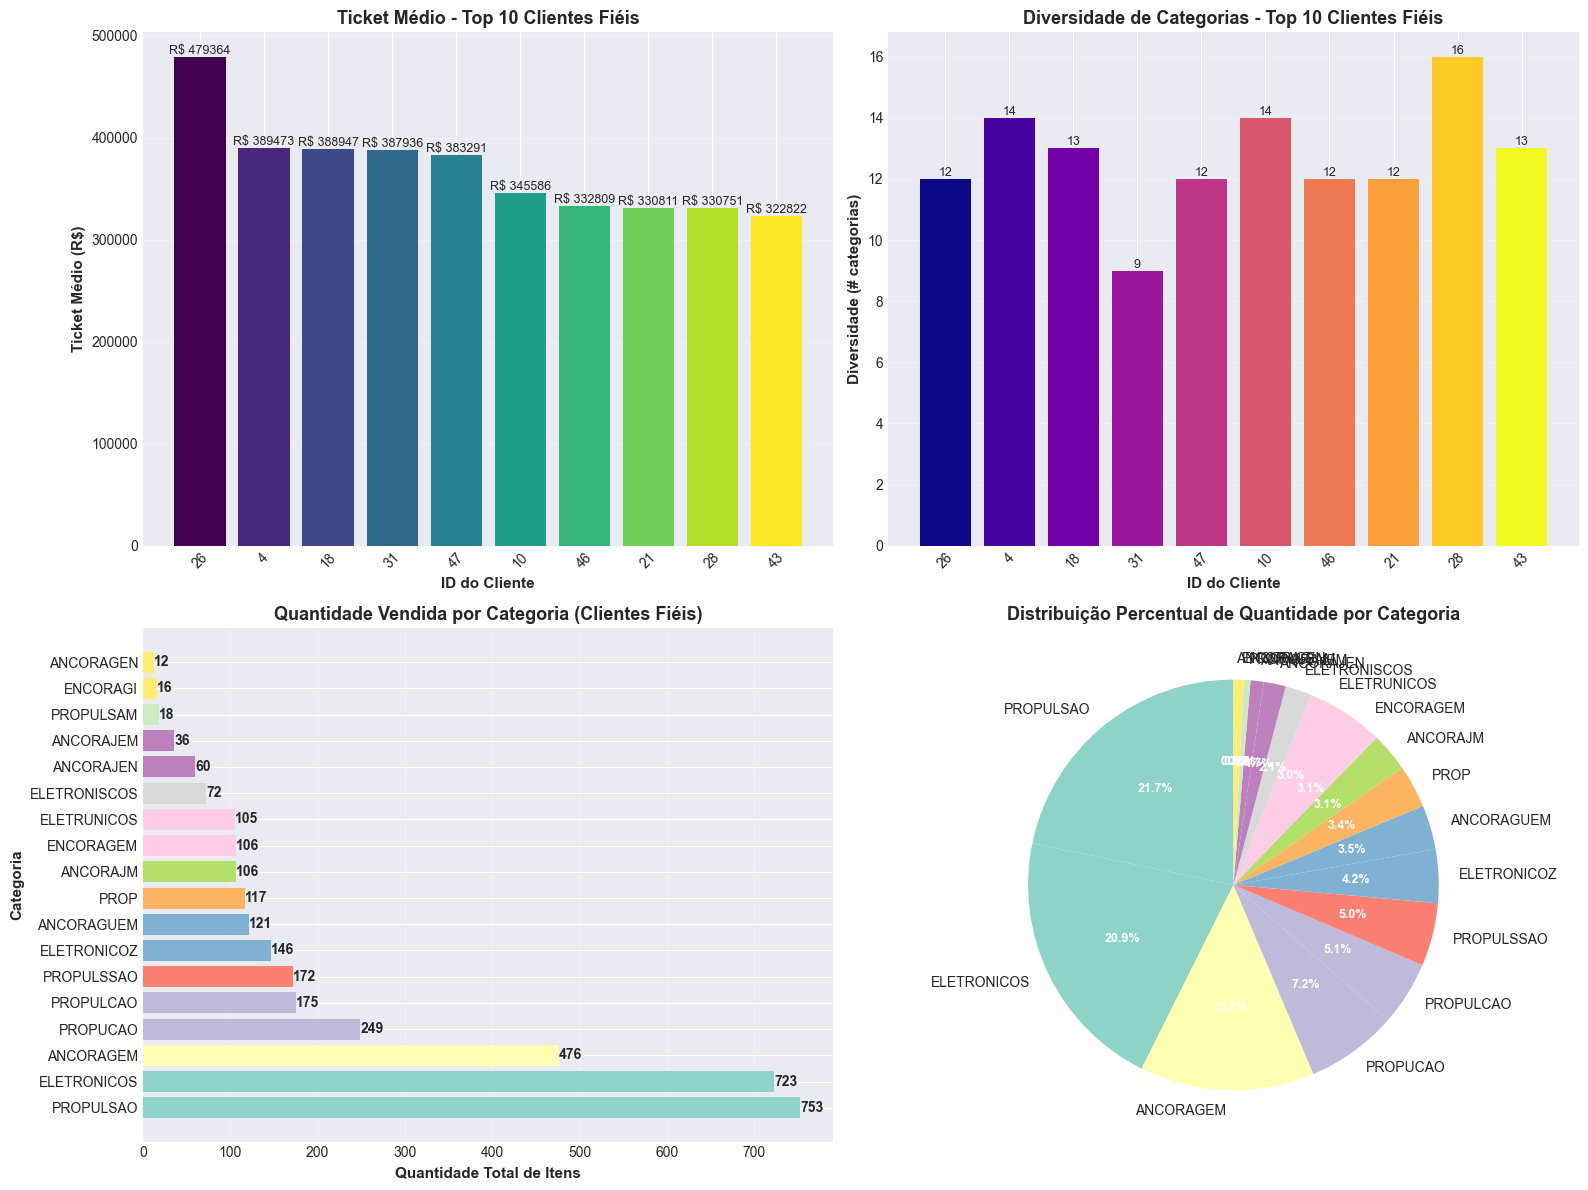


Gráficos gerados com sucesso!


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Ticket Médio dos 10 Clientes de Elite
ax1 = axes[0, 0]
x_pos = range(len(clientes_fieis))
colors_ticket = plt.cm.viridis(np.linspace(0, 1, len(clientes_fieis)))
bars1 = ax1.bar(x_pos, clientes_fieis['ticket_medio'], color=colors_ticket)
ax1.set_xlabel('ID do Cliente', fontsize=11, fontweight='bold')
ax1.set_ylabel('Ticket Médio (R$)', fontsize=11, fontweight='bold')
ax1.set_title('Ticket Médio - Top 10 Clientes Fiéis', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(clientes_fieis['id_client'].astype(int), rotation=45)
ax1.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'R$ {height:.0f}', ha='center', va='bottom', fontsize=9)

# Gráfico 2: Diversidade de Categorias
ax2 = axes[0, 1]
colors_div = plt.cm.plasma(np.linspace(0, 1, len(clientes_fieis)))
bars2 = ax2.bar(x_pos, clientes_fieis['diversidade_categorias'], color=colors_div)
ax2.set_xlabel('ID do Cliente', fontsize=11, fontweight='bold')
ax2.set_ylabel('Diversidade (# categorias)', fontsize=11, fontweight='bold')
ax2.set_title('Diversidade de Categorias - Top 10 Clientes Fiéis', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(clientes_fieis['id_client'].astype(int), rotation=45)
ax2.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.0f}', ha='center', va='bottom', fontsize=9)

# Gráfico 3: Distribuição de Quantidade por Categoria (Clientes Fiéis)
ax3 = axes[1, 0]
colors_cat = plt.cm.Set3(np.linspace(0, 1, len(categoria_vendida)))
bars3 = ax3.barh(categoria_vendida['categoria'], categoria_vendida['quantidade_total'], color=colors_cat)
ax3.set_xlabel('Quantidade Total de Itens', fontsize=11, fontweight='bold')
ax3.set_ylabel('Categoria', fontsize=11, fontweight='bold')
ax3.set_title('Quantidade Vendida por Categoria (Clientes Fiéis)', fontsize=13, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars3):
    width = bar.get_width()
    ax3.text(width, bar.get_y() + bar.get_height()/2.,
             f'{width:.0f}', ha='left', va='center', fontsize=10, fontweight='bold')

# Gráfico 4: Percentual por Categoria
ax4 = axes[1, 1]
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(categoria_vendida)))
wedges, texts, autotexts = ax4.pie(
    categoria_vendida['quantidade_total'],
    labels=categoria_vendida['categoria'],
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90
)
ax4.set_title('Distribuição Percentual de Quantidade por Categoria', fontsize=13, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

plt.tight_layout()
plt.show()

print('\nGráficos gerados com sucesso!')

## 7. Consulta SQL Equivalente (SQLite)

### Questão 5.1 - Código SQL

Este script SQL implementa toda a análise em SQL puro, utilizando CTEs e window functions para:
1. Normalizar e agrupar categorias
2. Calcular métricas de cliente (Ticket Médio e Diversidade)
3. Filtrar os 10 clientes fiéis com 3+ categorias
4. Identificar a categoria mais vendida para esses clientes

**Tabelas necessárias:**
- `vendas`: id, id_client, id_product, qtd, total, sale_date
- `produtos`: code, actual_category (ou usar `produtos_normalizado` já limpo)

**Para SQLite, use o script abaixo:**

```sql
-- PASSO 1: Criar mapeamento de categorias normalizadas (ou usar CASE/função)
WITH categorias_normalizadas AS (
    SELECT DISTINCT
        code,
        UPPER(TRIM(REPLACE(REPLACE(REPLACE(actual_category, ' ', ''), 'á', 'a'), 'â', 'a'))) AS categoria_norm
    FROM produtos
),

-- PASSO 2: Cruzar vendas com produtos normalizados e calcular métricas por cliente
metricas_cliente AS (
    SELECT
        v.id_client,
        SUM(v.total) AS faturamento_total,
        COUNT(DISTINCT v.id) AS frequencia,
        ROUND(SUM(v.total) * 1.0 / COUNT(DISTINCT v.id), 2) AS ticket_medio,
        COUNT(DISTINCT cn.categoria_norm) AS diversidade_categorias
    FROM vendas v
    LEFT JOIN categorias_normalizadas cn ON v.id_product = cn.code
    GROUP BY v.id_client
),

-- PASSO 3: Filtrar clientes de elite (3+ categorias) e ordenar
clientes_fieis AS (
    SELECT
        id_client,
        faturamento_total,
        frequencia,
        ticket_medio,
        diversidade_categorias,
        ROW_NUMBER() OVER (ORDER BY ticket_medio DESC, id_client ASC) AS ranking
    FROM metricas_cliente
    WHERE diversidade_categorias >= 3
),

-- PASSO 4: Selecionar top 10
top_10_fieis AS (
    SELECT *
    FROM clientes_fieis
    WHERE ranking <= 10
),

-- PASSO 5: Para esses 10 clientes, calcular quantidade por categoria
categoria_top_fieis AS (
    SELECT
        cn.categoria_norm AS categoria,
        SUM(v.qtd) AS quantidade_total,
        SUM(v.total) AS faturamento_total,
        COUNT(DISTINCT v.id) AS numero_transacoes
    FROM vendas v
    LEFT JOIN categorias_normalizadas cn ON v.id_product = cn.code
    LEFT JOIN top_10_fieis t10 ON v.id_client = t10.id_client
    WHERE t10.id_client IS NOT NULL
    GROUP BY cn.categoria_norm
    ORDER BY quantidade_total DESC
)

-- RESULTADO 1: Top 10 Clientes Fiéis
SELECT
    id_client,
    faturamento_total,
    frequencia,
    ticket_medio,
    diversidade_categorias,
    ranking
FROM top_10_fieis
ORDER BY ranking;

-- RESULTADO 2: Categoria Mais Vendida para Clientes Fiéis
SELECT
    categoria,
    quantidade_total,
    faturamento_total,
    numero_transacoes,
    ROUND(quantidade_total * 100.0 / (SELECT SUM(quantidade_total) FROM categoria_top_fieis), 2) AS percentual
FROM categoria_top_fieis;
```

### Alternativa Simplificada (Sem CTEs intermediárias)

```sql
-- Versão simplificada: calcular tudo em uma query
SELECT
    v.id_client,
    SUM(v.total) AS faturamento_total,
    COUNT(DISTINCT v.id) AS frequencia,
    ROUND(SUM(v.total) * 1.0 / COUNT(DISTINCT v.id), 2) AS ticket_medio,
    COUNT(DISTINCT UPPER(TRIM(p.actual_category))) AS diversidade_categorias
FROM vendas v
LEFT JOIN produtos p ON v.id_product = p.code
GROUP BY v.id_client
HAVING COUNT(DISTINCT UPPER(TRIM(p.actual_category))) >= 3
ORDER BY ticket_medio DESC, v.id_client ASC
LIMIT 10;
```